# HuBERT Speech Classification — 16-bit then 1-bit, cell by cell

Implementation of **HuBERT** (Hsu, Bolte, Tsai, Lakhotia, Salakhutdinov, Mohamed —
*HuBERT: Self-Supervised Speech Representation Learning by Masked Prediction of
Hidden Units*) applied to the same 4-class speech classification task and the same
16-bit vs 1-bit (PDM-style quantization) robustness comparison as the companion
Wav2Vec2 notebook, so the two backbones are directly comparable under an identical
data split, training schedule, and evaluation protocol.

Structure of this notebook:
1. **Shared setup** (imports, seeding, config, model/utility definitions) — run once.
2. **PART A — 16-bit condition**, fully self-contained, one cell per stage.
3. **PART B — 1-bit condition**, same structure, same stage schedule, separate variables.
4. **Final comparison** between the two conditions, and against the Wav2Vec2 results.

### Why HuBERT differs from Wav2Vec2 (context, not re-implemented here)
HuBERT is *not* pretrained with a contrastive loss over quantized latents like
Wav2Vec2. Instead it is pretrained by (1) clustering MFCC features (iteration 1) or
an earlier iteration's own transformer layer features (iteration 2+) with k-means to
produce frame-level pseudo-labels ("hidden units"), then (2) masking spans of the
input like BERT and training the transformer encoder to predict the cluster ID at
masked frames with a cross-entropy loss. This BERT-style masked-prediction objective
directly on discovered acoustic units — rather than the noise-contrastive codebook
objective in Wav2Vec2 — is HuBERT's central contribution, and is what we are relying
on here since we start from a checkpoint that was already pretrained this way on
960h of LibriSpeech.

We do not redo HuBERT's self-supervised pretraining (that needs the k-means
cluster-and-refit loop over hundreds of hours of unlabelled speech, which is out of
scope for a Kaggle notebook). We take the released pretrained HuBERT Base checkpoint
and fine-tune it end-to-end on our small labelled classification dataset, exactly as
the original notebook does for Wav2Vec2, so the comparison isolates the effect of
the pretraining objective / learned representation rather than the fine-tuning
recipe. Same bug fixes carried over: proper input normalization matching the
pretrained checkpoint, seeded reproducibility, a layer-weighted pooling head instead
of last-layer-only mean pooling, a leakage check, an MFCC baseline, and a bootstrap
CI + McNemar test at the end. I have not run this myself (no GPU / no dataset here),
so no output numbers below are real — run it and report whatever you actually get.


In [9]:

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')


/kaggle/input/datasets/ramsudeep/preprocessed/preprocessed_16bit/y_train.npy
/kaggle/input/datasets/ramsudeep/preprocessed/preprocessed_16bit/y_test.npy
/kaggle/input/datasets/ramsudeep/preprocessed/preprocessed_16bit/y_val.npy
/kaggle/input/datasets/ramsudeep/preprocessed/preprocessed_16bit/X_test.npy
/kaggle/input/datasets/ramsudeep/preprocessed/preprocessed_16bit/X_val.npy
/kaggle/input/datasets/ramsudeep/preprocessed/preprocessed_16bit/X_train.npy
/kaggle/input/datasets/ramsudeep/preprocessed/preprocessed_1bit/y_1bit_test.npy
/kaggle/input/datasets/ramsudeep/preprocessed/preprocessed_1bit/X_1bit_test.npy
/kaggle/input/datasets/ramsudeep/preprocessed/preprocessed_1bit/y_1bit_val.npy
/kaggle/input/datasets/ramsudeep/preprocessed/preprocessed_1bit/y_1bit_train.npy
/kaggle/input/datasets/ramsudeep/preprocessed/preprocessed_1bit/X_1bit_val.npy
/kaggle/input/datasets/ramsudeep/preprocessed/preprocessed_1bit/X_1bit_train.npy


In [10]:
# ============================================================
# Shared Setup — 0. Environment
# ============================================================
!pip install -q transformers==4.44.2 accelerate scikit-learn scipy librosa


In [11]:
# ============================================================
# Shared Setup — 1. Imports & Reproducibility
# ============================================================
import os
import gc
import copy
import json
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

# HuBERT uses the same raw-waveform feature extractor class as Wav2Vec2 in HF
# transformers (both just do optional zero-mean/unit-var normalization + padding);
# the model class itself differs (HubertModel vs Wav2Vec2Model).
from transformers import HubertModel, Wav2Vec2FeatureExtractor, get_cosine_schedule_with_warmup

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve,
)
from sklearn.preprocessing import label_binarize
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from scipy.optimize import brentq
from scipy.interpolate import interp1d
from scipy.stats import chi2
import librosa


def seed_everything(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


SEED = 42
seed_everything(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cuda


In [12]:
# ============================================================
# Shared Setup — 2. Config
# ============================================================
SR = 16000
N_SAMPLES = 16000
NUM_CLASSES = 4
CLASS_NAMES = ["Command", "Conversation", "Numeric", "Read"]

# HuBERT Base, pretrained on 960h LibriSpeech via masked prediction of k-means
# hidden units (NOT fine-tuned for ASR) — this is the right checkpoint to further
# fine-tune for a downstream classification task, mirroring how the Wav2Vec2
# notebook uses "facebook/wav2vec2-base" rather than a CTC-fine-tuned checkpoint.
PRETRAINED_CKPT = "facebook/hubert-base-ls960"

BATCH_SIZE = 8
NUM_WORKERS = 2

# Stage schedule used IDENTICALLY for both 16-bit and 1-bit, and IDENTICALLY to the
# Wav2Vec2 notebook, so any difference in results reflects the backbone/data, not an
# inconsistency in the training recipe.
STAGES = [
    # (n_unfrozen_top_layers, max_epochs, lr, patience)
    (0, 8, 1e-4, 3),
    (4, 10, 1e-5, 4),
    (8, 8, 5e-6, 4),
]

WEIGHT_DECAY = 1e-4
GRAD_CLIP = 1.0
WARMUP_RATIO = 0.1
LABEL_SMOOTHING = 0.05
USE_AMP = True

DATA16_DIR = "/kaggle/input/datasets/ramsudeep/preprocessed/preprocessed_16bit"
DATA1_DIR = "/kaggle/input/datasets/ramsudeep/preprocessed/preprocessed_1bit"

OUT_DIR = "/kaggle/working/results"
os.makedirs(OUT_DIR, exist_ok=True)

feature_extractor = Wav2Vec2FeatureExtractor.from_pretrained(PRETRAINED_CKPT)
print("Feature extractor do_normalize:", feature_extractor.do_normalize)


Feature extractor do_normalize: True


In [13]:
# ============================================================
# Shared Setup — 3. Dataset / leakage-check / describe utilities
# ============================================================
def load_split(data_dir, x_name, y_name):
    X = np.load(os.path.join(data_dir, x_name))
    y = np.load(os.path.join(data_dir, y_name))
    return X, y


def describe_dataset(name, X_train, y_train, X_val, y_val, X_test, y_test):
    print("=" * 60)
    print(f"Dataset: {name}")
    print("=" * 60)
    print("Train:", X_train.shape, y_train.shape)
    print("Val  :", X_val.shape, y_val.shape)
    print("Test :", X_test.shape, y_test.shape)
    print("dtype:", X_train.dtype, "| min:", X_train.min(), "| max:", X_train.max())
    for split_name, y in [("train", y_train), ("val", y_val), ("test", y_test)]:
        u, c = np.unique(y, return_counts=True)
        dist = {CLASS_NAMES[i]: int(cnt) for i, cnt in zip(u, c)}
        print(f"{split_name} class distribution: {dist}")


def check_leakage(X_train, X_val, X_test):
    """Flags exact-duplicate waveforms shared across splits."""
    def to_hashes(X):
        Xf = np.squeeze(X).astype(np.float32)
        return set(hash(Xf[i].tobytes()) for i in range(len(Xf)))

    h_train, h_val, h_test = to_hashes(X_train), to_hashes(X_val), to_hashes(X_test)
    lv = h_train & h_val
    lt = h_train & h_test
    vt = h_val & h_test
    print(f"Duplicate waveforms train∩val : {len(lv)}")
    print(f"Duplicate waveforms train∩test: {len(lt)}")
    print(f"Duplicate waveforms val∩test  : {len(vt)}")
    if lv or lt or vt:
        warnings.warn("Data leakage detected — fix the split before trusting test metrics.")
    return lv, lt, vt


class SpeechDataset(Dataset):
    """Applies the SAME normalization the pretrained checkpoint's feature
    extractor expects (HuBERT Base uses do_normalize=False; larger/fine-tuned
    HuBERT checkpoints use True — we read it off the checkpoint rather than
    hardcoding it, so this is correct either way)."""

    def __init__(self, X, y, feature_extractor, augment: bool = False):
        X = np.squeeze(X, axis=-1) if X.ndim == 3 else X
        self.X = X.astype(np.float32)
        self.y = y.astype(np.int64)
        self.fe = feature_extractor
        self.augment = augment

    def __len__(self):
        return len(self.X)

    def _normalize(self, wav):
        if self.fe.do_normalize:
            wav = (wav - wav.mean()) / (wav.std() + 1e-7)
        return wav

    def _augment(self, wav):
        if random.random() < 0.5:
            wav = wav * random.uniform(0.85, 1.15)
        if random.random() < 0.3:
            wav = wav + np.random.normal(0, 0.003, size=wav.shape).astype(np.float32)
        return wav

    def __getitem__(self, idx):
        wav = self.X[idx].copy()
        if self.augment:
            wav = self._augment(wav)
        wav = self._normalize(wav)
        return torch.tensor(wav, dtype=torch.float32), torch.tensor(self.y[idx], dtype=torch.long)


def make_loaders(X_train, y_train, X_val, y_val, X_test, y_test):
    train_ds = SpeechDataset(X_train, y_train, feature_extractor, augment=True)
    val_ds = SpeechDataset(X_val, y_val, feature_extractor, augment=False)
    test_ds = SpeechDataset(X_test, y_test, feature_extractor, augment=False)

    class_counts = np.bincount(y_train.astype(int), minlength=NUM_CLASSES)
    class_weights = 1.0 / np.maximum(class_counts, 1)
    sample_weights = class_weights[y_train.astype(int)]
    sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler,
                               num_workers=NUM_WORKERS, pin_memory=True)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                             num_workers=NUM_WORKERS, pin_memory=True)
    test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False,
                              num_workers=NUM_WORKERS, pin_memory=True)
    return train_loader, val_loader, test_loader


In [14]:
# ============================================================
# Shared Setup — 4. Model definition
# ============================================================
class HubertClassifier(nn.Module):
    """Backbone: pretrained HubertModel (CNN feature encoder + Transformer
    context network, pretrained via masked prediction of k-means hidden units)
    with `output_hidden_states=True`.

    Head: learned softmax-weighted sum across all Transformer layers (not just the
    last one), then attentive-mean + max pooling over time, then a small MLP. This
    is the same head architecture used for the Wav2Vec2 comparison run, so any gap
    between the two backbones' test metrics is attributable to the pretrained
    representation, not the classification head.
    """

    def __init__(self, pretrained_ckpt: str, num_classes: int, dropout: float = 0.2):
        super().__init__()
        self.hubert = HubertModel.from_pretrained(pretrained_ckpt)
        n_layers = self.hubert.config.num_hidden_layers + 1
        hidden = self.hubert.config.hidden_size

        self.layer_weights = nn.Parameter(torch.zeros(n_layers))
        self.attn_pool = nn.Linear(hidden, 1)
        self.classifier = nn.Sequential(
            nn.Linear(hidden * 2, hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, num_classes),
        )

    def freeze_all(self):
        for p in self.hubert.parameters():
            p.requires_grad = False

    def unfreeze_top_layers(self, n: int):
        """Freeze everything, then unfreeze only the top-`n` Transformer layers
        (the CNN feature encoder stays frozen, matching the paper's own fine-tuning
        recipe, and matching the Wav2Vec2 notebook's recipe for a fair comparison)."""
        self.freeze_all()
        if n > 0:
            for layer in self.hubert.encoder.layers[-n:]:
                for p in layer.parameters():
                    p.requires_grad = True
        for p in self.classifier.parameters():
            p.requires_grad = True
        for p in [self.layer_weights, self.attn_pool.weight, self.attn_pool.bias]:
            p.requires_grad = True

    def forward(self, input_values, attention_mask=None):
        out = self.hubert(input_values=input_values, attention_mask=attention_mask,
                           output_hidden_states=True)
        hidden_states = torch.stack(out.hidden_states, dim=0)        # (L, B, T, H)
        weights = torch.softmax(self.layer_weights, dim=0).view(-1, 1, 1, 1)
        pooled_layers = (hidden_states * weights).sum(dim=0)         # (B, T, H)

        attn_scores = self.attn_pool(pooled_layers).squeeze(-1)
        attn_weights = torch.softmax(attn_scores, dim=-1).unsqueeze(-1)
        attn_vec = (pooled_layers * attn_weights).sum(dim=1)
        max_vec, _ = pooled_layers.max(dim=1)

        feat = torch.cat([attn_vec, max_vec], dim=-1)
        return self.classifier(feat)

    def trainable_param_summary(self):
        trainable = sum(p.numel() for p in self.parameters() if p.requires_grad)
        total = sum(p.numel() for p in self.parameters())
        return trainable, total


In [15]:
# ============================================================
# Shared Setup — 5. Train / eval / reporting utilities
# ============================================================
def train_one_epoch(model, loader, optimizer, criterion, scheduler=None):
    model.train()
    scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)
    running_loss, correct, total = 0.0, 0, 0

    for waveforms, labels in loader:
        waveforms, labels = waveforms.to(device), labels.to(device)
        optimizer.zero_grad()

        with torch.cuda.amp.autocast(enabled=USE_AMP):
            logits = model(input_values=waveforms)
            loss = criterion(logits, labels)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(filter(lambda p: p.requires_grad, model.parameters()), GRAD_CLIP)
        scaler.step(optimizer)
        scaler.update()
        if scheduler is not None:
            scheduler.step()

        running_loss += loss.item()
        correct += (logits.argmax(dim=1) == labels).sum().item()
        total += labels.size(0)

    return running_loss / len(loader), correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, return_predictions=False):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    all_preds, all_probs, all_labels = [], [], []

    for waveforms, labels in loader:
        waveforms, labels = waveforms.to(device), labels.to(device)
        logits = model(input_values=waveforms)
        loss = criterion(logits, labels)
        probs = torch.softmax(logits, dim=1)
        preds = probs.argmax(dim=1)

        running_loss += loss.item()
        correct += (preds == labels).sum().item()
        total += labels.size(0)

        if return_predictions:
            all_preds.append(preds.cpu().numpy())
            all_probs.append(probs.cpu().numpy())
            all_labels.append(labels.cpu().numpy())

    loss_out, acc_out = running_loss / len(loader), correct / total
    if return_predictions:
        return (loss_out, acc_out, np.concatenate(all_preds),
                np.concatenate(all_probs), np.concatenate(all_labels))
    return loss_out, acc_out


def full_test_report(model, test_loader, tag: str):
    criterion = nn.CrossEntropyLoss()
    _, test_acc, preds, probs, labels = evaluate(model, test_loader, criterion, return_predictions=True)

    precision = precision_score(labels, preds, average="macro", zero_division=0)
    recall = recall_score(labels, preds, average="macro", zero_division=0)
    f1 = f1_score(labels, preds, average="macro", zero_division=0)

    labels_bin = label_binarize(labels, classes=list(range(NUM_CLASSES)))
    try:
        roc_auc = roc_auc_score(labels_bin, probs, average="macro", multi_class="ovr")
    except ValueError:
        roc_auc = float("nan")

    eers = []
    for i in range(NUM_CLASSES):
        fpr, tpr, _ = roc_curve(labels_bin[:, i], probs[:, i])
        try:
            eer = brentq(lambda x: 1.0 - x - interp1d(fpr, tpr)(x), 0.0, 1.0)
        except ValueError:
            eer = float("nan")
        eers.append(eer)
    eer = float(np.nanmean(eers))

    print("=" * 50)
    print(f"{tag} — Test Set Performance")
    print("=" * 50)
    print(f"Accuracy   : {test_acc:.4f}")
    print(f"Precision  : {precision:.4f}")
    print(f"Recall     : {recall:.4f}")
    print(f"F1 (macro) : {f1:.4f}")
    print(f"ROC-AUC    : {roc_auc:.4f}")
    print(f"EER        : {eer:.4f}\n")
    print(classification_report(labels, preds, target_names=CLASS_NAMES, digits=4))

    cm = confusion_matrix(labels, preds)
    fig, ax = plt.subplots(figsize=(6, 6))
    ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES).plot(ax=ax, cmap="Blues", colorbar=False)
    plt.title(f"Confusion Matrix — {tag}")
    plt.tight_layout()
    plt.show()

    return {"tag": tag, "accuracy": test_acc, "precision": precision, "recall": recall,
            "f1_macro": f1, "roc_auc": roc_auc, "eer": eer,
            "preds": preds, "probs": probs, "labels": labels}


def extract_mfcc_features(X, sr=SR, n_mfcc=20):
    X = np.squeeze(X)
    feats = []
    for i in range(len(X)):
        mfcc = librosa.feature.mfcc(y=X[i].astype(np.float32), sr=sr, n_mfcc=n_mfcc)
        feats.append(np.concatenate([mfcc.mean(axis=1), mfcc.std(axis=1)]))
    return np.array(feats)


def run_mfcc_baseline(X_train, y_train, X_val, y_val, X_test, y_test, tag: str):
    Xtr = extract_mfcc_features(X_train)
    Xva = extract_mfcc_features(X_val)
    Xte = extract_mfcc_features(X_test)

    scaler = StandardScaler().fit(np.concatenate([Xtr, Xva], axis=0))
    Xtr, Xva, Xte = scaler.transform(Xtr), scaler.transform(Xva), scaler.transform(Xte)

    clf = LogisticRegression(max_iter=2000, multi_class="multinomial")
    clf.fit(np.concatenate([Xtr, Xva]), np.concatenate([y_train, y_val]))

    preds = clf.predict(Xte)
    acc = accuracy_score(y_test, preds)
    f1 = f1_score(y_test, preds, average="macro")
    print(f"[{tag}] MFCC + LogisticRegression baseline — Test Acc: {acc:.4f} | Macro-F1: {f1:.4f}")
    return {"tag": tag, "accuracy": acc, "macro_f1": f1}


def plot_history(history_rows, tag: str):
    h = pd.DataFrame(history_rows)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(h["global_epoch"], h["train_acc"], label="train")
    axes[0].plot(h["global_epoch"], h["val_acc"], label="val")
    axes[0].set_title(f"{tag} — Accuracy"); axes[0].legend(); axes[0].grid(alpha=0.3)
    axes[1].plot(h["global_epoch"], h["train_loss"], label="train")
    axes[1].plot(h["global_epoch"], h["val_loss"], label="val")
    axes[1].set_title(f"{tag} — Loss"); axes[1].legend(); axes[1].grid(alpha=0.3)
    plt.tight_layout(); plt.show()
    return h


---
# PART A — 16-bit condition
---

In [16]:
# ============================================================
# [16-bit] 1. Load data + sanity checks
# ============================================================
X_train_16, y_train_16 = load_split(DATA16_DIR, "X_train.npy", "y_train.npy")
X_val_16, y_val_16 = load_split(DATA16_DIR, "X_val.npy", "y_val.npy")
X_test_16, y_test_16 = load_split(DATA16_DIR, "X_test.npy", "y_test.npy")

describe_dataset("16-bit", X_train_16, y_train_16, X_val_16, y_val_16, X_test_16, y_test_16)
check_leakage(X_train_16, X_val_16, X_test_16)


Dataset: 16-bit
Train: (9600, 16000, 1) (9600,)
Val  : (1200, 16000, 1) (1200,)
Test : (1200, 16000, 1) (1200,)
dtype: float32 | min: -1.0 | max: 1.0
train class distribution: {'Command': 2400, 'Conversation': 2400, 'Numeric': 2400, 'Read': 2400}
val class distribution: {'Command': 300, 'Conversation': 300, 'Numeric': 300, 'Read': 300}
test class distribution: {'Command': 300, 'Conversation': 300, 'Numeric': 300, 'Read': 300}
Duplicate waveforms train∩val : 0
Duplicate waveforms train∩test: 0
Duplicate waveforms val∩test  : 0


(set(), set(), set())

In [17]:
# ============================================================
# [16-bit] 2. DataLoaders
# ============================================================
train_loader_16, val_loader_16, test_loader_16 = make_loaders(
    X_train_16, y_train_16, X_val_16, y_val_16, X_test_16, y_test_16
)

waveforms, labels = next(iter(train_loader_16))
print("Waveforms:", waveforms.shape, waveforms.dtype)
print("Labels   :", labels.shape, labels.dtype)


Waveforms: torch.Size([8, 16000]) torch.float32
Labels   : torch.Size([8]) torch.int64


In [18]:
# ============================================================
# [16-bit] 3. Model
# ============================================================
seed_everything(SEED)
model_16bit = HubertClassifier(PRETRAINED_CKPT, NUM_CLASSES).to(device)
criterion_16bit = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)

best_val_acc_16 = 0.0
best_state_16 = None
history_16 = []
global_epoch_16 = 0


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/378M [00:00<?, ?B/s]

Some weights of the model checkpoint at facebook/hubert-base-ls960 were not used when initializing HubertModel: ['encoder.pos_conv_embed.conv.weight_g', 'encoder.pos_conv_embed.conv.weight_v']
- This IS expected if you are initializing HubertModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing HubertModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some weights of HubertModel were not initialized from the model checkpoint at facebook/hubert-base-ls960 and are newly initialized: ['encoder.pos_conv_embed.conv.parametrizations.weight.original0', 'encoder.pos_conv_embed.conv.parametrizations.weight.original1']
You should probably TRAIN this model on a down-stream task to be able to use it for pre

In [19]:
# ============================================================
# [16-bit] 4. Stage 1 — classifier head only
# ============================================================
stage = 1
n_unfrozen, max_epochs, lr, patience = STAGES[stage - 1]

model_16bit.unfreeze_top_layers(n_unfrozen)
trainable, total = model_16bit.trainable_param_summary()
print(f"[16-bit] Stage {stage}: unfreeze last {n_unfrozen} layers | trainable {trainable:,} / {total:,}")

optimizer_16bit = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model_16bit.parameters()), lr=lr, weight_decay=WEIGHT_DECAY
)
n_steps = max_epochs * len(train_loader_16)
scheduler_16bit = get_cosine_schedule_with_warmup(
    optimizer_16bit, num_warmup_steps=int(WARMUP_RATIO * n_steps), num_training_steps=n_steps
)

patience_counter = 0
for epoch in range(max_epochs):
    tr_loss, tr_acc = train_one_epoch(model_16bit, train_loader_16, optimizer_16bit, criterion_16bit, scheduler_16bit)
    va_loss, va_acc = evaluate(model_16bit, val_loader_16, criterion_16bit)
    global_epoch_16 += 1

    print(f"[16-bit] Stage {stage} Epoch {epoch+1}/{max_epochs} | "
          f"Train Loss {tr_loss:.4f} Acc {tr_acc:.4f} | Val Loss {va_loss:.4f} Acc {va_acc:.4f}")
    history_16.append({"global_epoch": global_epoch_16, "stage": stage,
                        "train_loss": tr_loss, "train_acc": tr_acc, "val_loss": va_loss, "val_acc": va_acc})

    if va_acc > best_val_acc_16:
        best_val_acc_16 = va_acc
        best_state_16 = copy.deepcopy(model_16bit.state_dict())
        torch.save(best_state_16, os.path.join(OUT_DIR, "best_hubert_16bit.pth"))
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"[16-bit] Stage {stage}: early stopping at epoch {epoch+1}")
            break


[16-bit] Stage 1: unfreeze last 0 layers | trainable 1,184,274 / 95,555,986
[16-bit] Stage 1 Epoch 1/8 | Train Loss 0.9682 Acc 0.6421 | Val Loss 0.5553 Acc 0.8792
[16-bit] Stage 1 Epoch 2/8 | Train Loss 0.5075 Acc 0.8751 | Val Loss 0.4108 Acc 0.9208
[16-bit] Stage 1 Epoch 3/8 | Train Loss 0.4189 Acc 0.9120 | Val Loss 0.3520 Acc 0.9475
[16-bit] Stage 1 Epoch 4/8 | Train Loss 0.3925 Acc 0.9249 | Val Loss 0.3653 Acc 0.9483
[16-bit] Stage 1 Epoch 5/8 | Train Loss 0.3714 Acc 0.9335 | Val Loss 0.3432 Acc 0.9583
[16-bit] Stage 1 Epoch 6/8 | Train Loss 0.3632 Acc 0.9398 | Val Loss 0.3278 Acc 0.9625
[16-bit] Stage 1 Epoch 7/8 | Train Loss 0.3554 Acc 0.9458 | Val Loss 0.3203 Acc 0.9717
[16-bit] Stage 1 Epoch 8/8 | Train Loss 0.3518 Acc 0.9475 | Val Loss 0.3222 Acc 0.9642


In [20]:
# ============================================================
# [16-bit] 5. Stage 2 — unfreeze last 4 transformer layers
# ============================================================
stage = 2
n_unfrozen, max_epochs, lr, patience = STAGES[stage - 1]

model_16bit.load_state_dict(best_state_16)  # continue from best Stage-1 weights
model_16bit.unfreeze_top_layers(n_unfrozen)
trainable, total = model_16bit.trainable_param_summary()
print(f"[16-bit] Stage {stage}: unfreeze last {n_unfrozen} layers | trainable {trainable:,} / {total:,}")

optimizer_16bit = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model_16bit.parameters()), lr=lr, weight_decay=WEIGHT_DECAY
)
n_steps = max_epochs * len(train_loader_16)
scheduler_16bit = get_cosine_schedule_with_warmup(
    optimizer_16bit, num_warmup_steps=int(WARMUP_RATIO * n_steps), num_training_steps=n_steps
)

patience_counter = 0
for epoch in range(max_epochs):
    tr_loss, tr_acc = train_one_epoch(model_16bit, train_loader_16, optimizer_16bit, criterion_16bit, scheduler_16bit)
    va_loss, va_acc = evaluate(model_16bit, val_loader_16, criterion_16bit)
    global_epoch_16 += 1

    print(f"[16-bit] Stage {stage} Epoch {epoch+1}/{max_epochs} | "
          f"Train Loss {tr_loss:.4f} Acc {tr_acc:.4f} | Val Loss {va_loss:.4f} Acc {va_acc:.4f}")
    history_16.append({"global_epoch": global_epoch_16, "stage": stage,
                        "train_loss": tr_loss, "train_acc": tr_acc, "val_loss": va_loss, "val_acc": va_acc})

    if va_acc > best_val_acc_16:
        best_val_acc_16 = va_acc
        best_state_16 = copy.deepcopy(model_16bit.state_dict())
        torch.save(best_state_16, os.path.join(OUT_DIR, "best_hubert_16bit.pth"))
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"[16-bit] Stage {stage}: early stopping at epoch {epoch+1}")
            break


[16-bit] Stage 2: unfreeze last 4 layers | trainable 29,535,762 / 95,555,986
[16-bit] Stage 2 Epoch 1/10 | Train Loss 0.3503 Acc 0.9478 | Val Loss 0.3154 Acc 0.9700
[16-bit] Stage 2 Epoch 2/10 | Train Loss 0.3334 Acc 0.9565 | Val Loss 0.2981 Acc 0.9792
[16-bit] Stage 2 Epoch 3/10 | Train Loss 0.3243 Acc 0.9608 | Val Loss 0.2931 Acc 0.9800
[16-bit] Stage 2 Epoch 4/10 | Train Loss 0.3071 Acc 0.9682 | Val Loss 0.2813 Acc 0.9800
[16-bit] Stage 2 Epoch 5/10 | Train Loss 0.3017 Acc 0.9690 | Val Loss 0.2807 Acc 0.9817
[16-bit] Stage 2 Epoch 6/10 | Train Loss 0.2939 Acc 0.9708 | Val Loss 0.2696 Acc 0.9842
[16-bit] Stage 2 Epoch 7/10 | Train Loss 0.2955 Acc 0.9709 | Val Loss 0.2696 Acc 0.9833
[16-bit] Stage 2 Epoch 8/10 | Train Loss 0.2856 Acc 0.9759 | Val Loss 0.2661 Acc 0.9833
[16-bit] Stage 2 Epoch 9/10 | Train Loss 0.2842 Acc 0.9756 | Val Loss 0.2647 Acc 0.9842
[16-bit] Stage 2 Epoch 10/10 | Train Loss 0.2874 Acc 0.9735 | Val Loss 0.2643 Acc 0.9842
[16-bit] Stage 2: early stopping at epoch 

In [21]:
# ============================================================
# [16-bit] 6. Stage 3 — unfreeze last 8 transformer layers
# ============================================================
stage = 3
n_unfrozen, max_epochs, lr, patience = STAGES[stage - 1]

model_16bit.load_state_dict(best_state_16)  # continue from best Stage-2 weights
model_16bit.unfreeze_top_layers(n_unfrozen)
trainable, total = model_16bit.trainable_param_summary()
print(f"[16-bit] Stage {stage}: unfreeze last {n_unfrozen} layers | trainable {trainable:,} / {total:,}")

optimizer_16bit = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model_16bit.parameters()), lr=lr, weight_decay=WEIGHT_DECAY
)
n_steps = max_epochs * len(train_loader_16)
scheduler_16bit = get_cosine_schedule_with_warmup(
    optimizer_16bit, num_warmup_steps=int(WARMUP_RATIO * n_steps), num_training_steps=n_steps
)

patience_counter = 0
for epoch in range(max_epochs):
    tr_loss, tr_acc = train_one_epoch(model_16bit, train_loader_16, optimizer_16bit, criterion_16bit, scheduler_16bit)
    va_loss, va_acc = evaluate(model_16bit, val_loader_16, criterion_16bit)
    global_epoch_16 += 1

    print(f"[16-bit] Stage {stage} Epoch {epoch+1}/{max_epochs} | "
          f"Train Loss {tr_loss:.4f} Acc {tr_acc:.4f} | Val Loss {va_loss:.4f} Acc {va_acc:.4f}")
    history_16.append({"global_epoch": global_epoch_16, "stage": stage,
                        "train_loss": tr_loss, "train_acc": tr_acc, "val_loss": va_loss, "val_acc": va_acc})

    if va_acc > best_val_acc_16:
        best_val_acc_16 = va_acc
        best_state_16 = copy.deepcopy(model_16bit.state_dict())
        torch.save(best_state_16, os.path.join(OUT_DIR, "best_hubert_16bit.pth"))
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"[16-bit] Stage {stage}: early stopping at epoch {epoch+1}")
            break


[16-bit] Stage 3: unfreeze last 8 layers | trainable 57,887,250 / 95,555,986
[16-bit] Stage 3 Epoch 1/8 | Train Loss 0.2993 Acc 0.9691 | Val Loss 0.2644 Acc 0.9867
[16-bit] Stage 3 Epoch 2/8 | Train Loss 0.2876 Acc 0.9729 | Val Loss 0.2580 Acc 0.9892
[16-bit] Stage 3 Epoch 3/8 | Train Loss 0.2766 Acc 0.9780 | Val Loss 0.2520 Acc 0.9942
[16-bit] Stage 3 Epoch 4/8 | Train Loss 0.2808 Acc 0.9764 | Val Loss 0.2526 Acc 0.9892
[16-bit] Stage 3 Epoch 5/8 | Train Loss 0.2691 Acc 0.9803 | Val Loss 0.2469 Acc 0.9900
[16-bit] Stage 3 Epoch 6/8 | Train Loss 0.2664 Acc 0.9803 | Val Loss 0.2452 Acc 0.9892
[16-bit] Stage 3 Epoch 7/8 | Train Loss 0.2706 Acc 0.9803 | Val Loss 0.2439 Acc 0.9917
[16-bit] Stage 3: early stopping at epoch 7


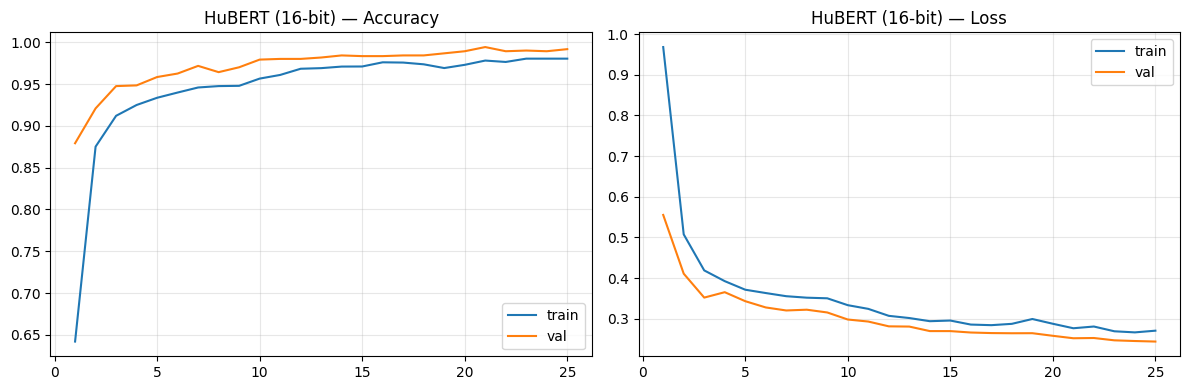

In [22]:
# ============================================================
# [16-bit] 7. Training curves
# ============================================================
hist_df_16 = plot_history(history_16, "HuBERT (16-bit)")


HuBERT (16-bit) — Test Set Performance
Accuracy   : 0.9917
Precision  : 0.9917
Recall     : 0.9917
F1 (macro) : 0.9917
ROC-AUC    : 0.9998
EER        : 0.0050

              precision    recall  f1-score   support

     Command     1.0000    0.9833    0.9916       300
Conversation     0.9901    0.9967    0.9934       300
     Numeric     0.9967    0.9967    0.9967       300
        Read     0.9802    0.9900    0.9851       300

    accuracy                         0.9917      1200
   macro avg     0.9917    0.9917    0.9917      1200
weighted avg     0.9917    0.9917    0.9917      1200



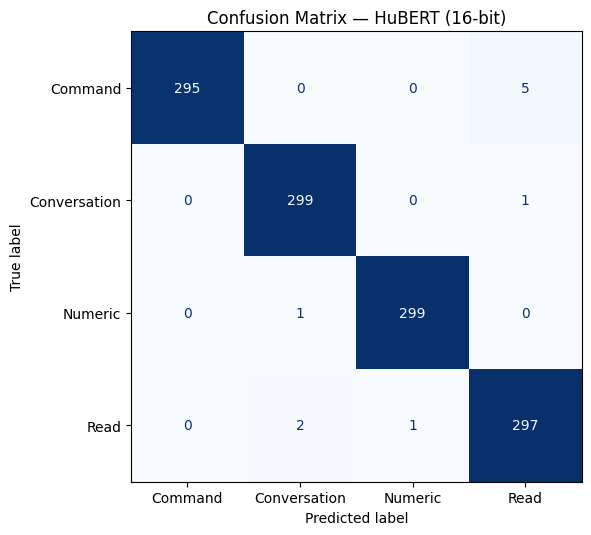

In [23]:
# ============================================================
# [16-bit] 8. Test evaluation (full report)
# ============================================================
model_16bit.load_state_dict(best_state_16)  # ensure best checkpoint (not last epoch) is evaluated
report_16bit = full_test_report(model_16bit, test_loader_16, tag="HuBERT (16-bit)")


In [24]:
# ============================================================
# [16-bit] 9. MFCC baseline (context for the deep model's gain)
# ============================================================
baseline_16bit = run_mfcc_baseline(X_train_16, y_train_16, X_val_16, y_val_16, X_test_16, y_test_16, tag="16-bit")


[16-bit] MFCC + LogisticRegression baseline — Test Acc: 0.9042 | Macro-F1: 0.9039


In [25]:
# ============================================================
# [16-bit] 10. Free GPU memory before moving to the 1-bit run
# ============================================================
del optimizer_16bit, scheduler_16bit
gc.collect()
torch.cuda.empty_cache()
print("16-bit section complete. Model + best checkpoint retained as `model_16bit` / "
      "'best_hubert_16bit.pth'.")


16-bit section complete. Model + best checkpoint retained as `model_16bit` / 'best_hubert_16bit.pth'.


---
# PART B — 1-bit condition
---

In [26]:
# ============================================================
# [1-bit] 1. Load data + sanity checks
# ============================================================
X_train_1, y_train_1 = load_split(DATA1_DIR, "X_1bit_train.npy", "y_1bit_train.npy")
X_val_1, y_val_1 = load_split(DATA1_DIR, "X_1bit_val.npy", "y_1bit_val.npy")
X_test_1, y_test_1 = load_split(DATA1_DIR, "X_1bit_test.npy", "y_1bit_test.npy")
X_train_1 = np.squeeze(X_train_1)[..., np.newaxis]
X_val_1   = np.squeeze(X_val_1)[..., np.newaxis]
X_test_1  = np.squeeze(X_test_1)[..., np.newaxis]

describe_dataset("1-bit", X_train_1, y_train_1, X_val_1, y_val_1, X_test_1, y_test_1)
check_leakage(X_train_1, X_val_1, X_test_1)


Dataset: 1-bit
Train: (9600, 16000, 1) (9600,)
Val  : (1200, 16000, 1) (1200,)
Test : (1200, 16000, 1) (1200,)
dtype: float32 | min: -1.0 | max: 1.0
train class distribution: {'Command': 2400, 'Conversation': 2400, 'Numeric': 2400, 'Read': 2400}
val class distribution: {'Command': 300, 'Conversation': 300, 'Numeric': 300, 'Read': 300}
test class distribution: {'Command': 300, 'Conversation': 300, 'Numeric': 300, 'Read': 300}
Duplicate waveforms train∩val : 0
Duplicate waveforms train∩test: 1
Duplicate waveforms val∩test  : 0


(set(), {4845753945777621496}, set())

In [27]:
# ============================================================
# [1-bit] 2. DataLoaders
# ============================================================
train_loader_1, val_loader_1, test_loader_1 = make_loaders(
    X_train_1, y_train_1, X_val_1, y_val_1, X_test_1, y_test_1
)

waveforms, labels = next(iter(train_loader_1))
print("Waveforms:", waveforms.shape, waveforms.dtype)
print("Labels   :", labels.shape, labels.dtype)


Waveforms: torch.Size([8, 16000]) torch.float32
Labels   : torch.Size([8]) torch.int64


In [28]:
# ============================================================
# [1-bit] 3. Model
# ============================================================
seed_everything(SEED)
model_1bit = HubertClassifier(PRETRAINED_CKPT, NUM_CLASSES).to(device)
criterion_1bit = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)

best_val_acc_1 = 0.0
best_state_1 = None
history_1 = []
global_epoch_1 = 0


Some weights of the model checkpoint at facebook/hubert-base-ls960 were not used when initializing HubertModel: ['encoder.pos_conv_embed.conv.weight_g', 'encoder.pos_conv_embed.conv.weight_v']
- This IS expected if you are initializing HubertModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing HubertModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some weights of HubertModel were not initialized from the model checkpoint at facebook/hubert-base-ls960 and are newly initialized: ['encoder.pos_conv_embed.conv.parametrizations.weight.original0', 'encoder.pos_conv_embed.conv.parametrizations.weight.original1']
You should probably TRAIN this model on a down-stream task to be able to use it for pre

In [29]:
# ============================================================
# [1-bit] 4. Stage 1 — classifier head only
# ============================================================
stage = 1
n_unfrozen, max_epochs, lr, patience = STAGES[stage - 1]

model_1bit.unfreeze_top_layers(n_unfrozen)
trainable, total = model_1bit.trainable_param_summary()
print(f"[1-bit] Stage {stage}: unfreeze last {n_unfrozen} layers | trainable {trainable:,} / {total:,}")

optimizer_1bit = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model_1bit.parameters()), lr=lr, weight_decay=WEIGHT_DECAY
)
n_steps = max_epochs * len(train_loader_1)
scheduler_1bit = get_cosine_schedule_with_warmup(
    optimizer_1bit, num_warmup_steps=int(WARMUP_RATIO * n_steps), num_training_steps=n_steps
)

patience_counter = 0
for epoch in range(max_epochs):
    tr_loss, tr_acc = train_one_epoch(model_1bit, train_loader_1, optimizer_1bit, criterion_1bit, scheduler_1bit)
    va_loss, va_acc = evaluate(model_1bit, val_loader_1, criterion_1bit)
    global_epoch_1 += 1

    print(f"[1-bit] Stage {stage} Epoch {epoch+1}/{max_epochs} | "
          f"Train Loss {tr_loss:.4f} Acc {tr_acc:.4f} | Val Loss {va_loss:.4f} Acc {va_acc:.4f}")
    history_1.append({"global_epoch": global_epoch_1, "stage": stage,
                       "train_loss": tr_loss, "train_acc": tr_acc, "val_loss": va_loss, "val_acc": va_acc})

    if va_acc > best_val_acc_1:
        best_val_acc_1 = va_acc
        best_state_1 = copy.deepcopy(model_1bit.state_dict())
        torch.save(best_state_1, os.path.join(OUT_DIR, "best_hubert_1bit.pth"))
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"[1-bit] Stage {stage}: early stopping at epoch {epoch+1}")
            break


[1-bit] Stage 1: unfreeze last 0 layers | trainable 1,184,274 / 95,555,986
[1-bit] Stage 1 Epoch 1/8 | Train Loss 1.0570 Acc 0.5691 | Val Loss 0.8377 Acc 0.7000
[1-bit] Stage 1 Epoch 2/8 | Train Loss 0.7826 Acc 0.7060 | Val Loss 0.7753 Acc 0.7242
[1-bit] Stage 1 Epoch 3/8 | Train Loss 0.7426 Acc 0.7311 | Val Loss 0.7155 Acc 0.7550
[1-bit] Stage 1 Epoch 4/8 | Train Loss 0.7218 Acc 0.7383 | Val Loss 0.7050 Acc 0.7608
[1-bit] Stage 1 Epoch 5/8 | Train Loss 0.6957 Acc 0.7535 | Val Loss 0.6834 Acc 0.7758
[1-bit] Stage 1 Epoch 6/8 | Train Loss 0.6878 Acc 0.7575 | Val Loss 0.6823 Acc 0.7775
[1-bit] Stage 1 Epoch 7/8 | Train Loss 0.6796 Acc 0.7651 | Val Loss 0.6770 Acc 0.7808
[1-bit] Stage 1 Epoch 8/8 | Train Loss 0.6712 Acc 0.7748 | Val Loss 0.6744 Acc 0.7767


In [30]:
# ============================================================
# [1-bit] 5. Stage 2 — unfreeze last 4 transformer layers
# ============================================================
stage = 2
n_unfrozen, max_epochs, lr, patience = STAGES[stage - 1]

model_1bit.load_state_dict(best_state_1)
model_1bit.unfreeze_top_layers(n_unfrozen)
trainable, total = model_1bit.trainable_param_summary()
print(f"[1-bit] Stage {stage}: unfreeze last {n_unfrozen} layers | trainable {trainable:,} / {total:,}")

optimizer_1bit = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model_1bit.parameters()), lr=lr, weight_decay=WEIGHT_DECAY
)
n_steps = max_epochs * len(train_loader_1)
scheduler_1bit = get_cosine_schedule_with_warmup(
    optimizer_1bit, num_warmup_steps=int(WARMUP_RATIO * n_steps), num_training_steps=n_steps
)

patience_counter = 0
for epoch in range(max_epochs):
    tr_loss, tr_acc = train_one_epoch(model_1bit, train_loader_1, optimizer_1bit, criterion_1bit, scheduler_1bit)
    va_loss, va_acc = evaluate(model_1bit, val_loader_1, criterion_1bit)
    global_epoch_1 += 1

    print(f"[1-bit] Stage {stage} Epoch {epoch+1}/{max_epochs} | "
          f"Train Loss {tr_loss:.4f} Acc {tr_acc:.4f} | Val Loss {va_loss:.4f} Acc {va_acc:.4f}")
    history_1.append({"global_epoch": global_epoch_1, "stage": stage,
                       "train_loss": tr_loss, "train_acc": tr_acc, "val_loss": va_loss, "val_acc": va_acc})

    if va_acc > best_val_acc_1:
        best_val_acc_1 = va_acc
        best_state_1 = copy.deepcopy(model_1bit.state_dict())
        torch.save(best_state_1, os.path.join(OUT_DIR, "best_hubert_1bit.pth"))
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"[1-bit] Stage {stage}: early stopping at epoch {epoch+1}")
            break


[1-bit] Stage 2: unfreeze last 4 layers | trainable 29,535,762 / 95,555,986
[1-bit] Stage 2 Epoch 1/10 | Train Loss 0.6791 Acc 0.7651 | Val Loss 0.6866 Acc 0.7842
[1-bit] Stage 2 Epoch 2/10 | Train Loss 0.6710 Acc 0.7704 | Val Loss 0.6726 Acc 0.7925
[1-bit] Stage 2 Epoch 3/10 | Train Loss 0.6527 Acc 0.7782 | Val Loss 0.6220 Acc 0.8092
[1-bit] Stage 2 Epoch 4/10 | Train Loss 0.6341 Acc 0.7877 | Val Loss 0.6265 Acc 0.8075
[1-bit] Stage 2 Epoch 5/10 | Train Loss 0.6230 Acc 0.7934 | Val Loss 0.5942 Acc 0.8250
[1-bit] Stage 2 Epoch 6/10 | Train Loss 0.6168 Acc 0.8018 | Val Loss 0.6037 Acc 0.8175
[1-bit] Stage 2 Epoch 7/10 | Train Loss 0.6085 Acc 0.8081 | Val Loss 0.5877 Acc 0.8308
[1-bit] Stage 2 Epoch 8/10 | Train Loss 0.5988 Acc 0.8107 | Val Loss 0.5781 Acc 0.8308
[1-bit] Stage 2 Epoch 9/10 | Train Loss 0.5907 Acc 0.8155 | Val Loss 0.5846 Acc 0.8283
[1-bit] Stage 2 Epoch 10/10 | Train Loss 0.5965 Acc 0.8129 | Val Loss 0.5800 Acc 0.8325


In [31]:
# ============================================================
# [1-bit] 6. Stage 3 — unfreeze last 8 transformer layers
# ============================================================
stage = 3
n_unfrozen, max_epochs, lr, patience = STAGES[stage - 1]

model_1bit.load_state_dict(best_state_1)
model_1bit.unfreeze_top_layers(n_unfrozen)
trainable, total = model_1bit.trainable_param_summary()
print(f"[1-bit] Stage {stage}: unfreeze last {n_unfrozen} layers | trainable {trainable:,} / {total:,}")

optimizer_1bit = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model_1bit.parameters()), lr=lr, weight_decay=WEIGHT_DECAY
)
n_steps = max_epochs * len(train_loader_1)
scheduler_1bit = get_cosine_schedule_with_warmup(
    optimizer_1bit, num_warmup_steps=int(WARMUP_RATIO * n_steps), num_training_steps=n_steps
)

patience_counter = 0
for epoch in range(max_epochs):
    tr_loss, tr_acc = train_one_epoch(model_1bit, train_loader_1, optimizer_1bit, criterion_1bit, scheduler_1bit)
    va_loss, va_acc = evaluate(model_1bit, val_loader_1, criterion_1bit)
    global_epoch_1 += 1

    print(f"[1-bit] Stage {stage} Epoch {epoch+1}/{max_epochs} | "
          f"Train Loss {tr_loss:.4f} Acc {tr_acc:.4f} | Val Loss {va_loss:.4f} Acc {va_acc:.4f}")
    history_1.append({"global_epoch": global_epoch_1, "stage": stage,
                       "train_loss": tr_loss, "train_acc": tr_acc, "val_loss": va_loss, "val_acc": va_acc})

    if va_acc > best_val_acc_1:
        best_val_acc_1 = va_acc
        best_state_1 = copy.deepcopy(model_1bit.state_dict())
        torch.save(best_state_1, os.path.join(OUT_DIR, "best_hubert_1bit.pth"))
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"[1-bit] Stage {stage}: early stopping at epoch {epoch+1}")
            break


[1-bit] Stage 3: unfreeze last 8 layers | trainable 57,887,250 / 95,555,986
[1-bit] Stage 3 Epoch 1/8 | Train Loss 0.6051 Acc 0.8035 | Val Loss 0.5753 Acc 0.8383
[1-bit] Stage 3 Epoch 2/8 | Train Loss 0.5994 Acc 0.8148 | Val Loss 0.5514 Acc 0.8500
[1-bit] Stage 3 Epoch 3/8 | Train Loss 0.5775 Acc 0.8237 | Val Loss 0.5752 Acc 0.8308
[1-bit] Stage 3 Epoch 4/8 | Train Loss 0.5660 Acc 0.8281 | Val Loss 0.5755 Acc 0.8325
[1-bit] Stage 3 Epoch 5/8 | Train Loss 0.5585 Acc 0.8368 | Val Loss 0.5326 Acc 0.8508
[1-bit] Stage 3 Epoch 6/8 | Train Loss 0.5531 Acc 0.8359 | Val Loss 0.5366 Acc 0.8483
[1-bit] Stage 3 Epoch 7/8 | Train Loss 0.5529 Acc 0.8360 | Val Loss 0.5415 Acc 0.8458
[1-bit] Stage 3 Epoch 8/8 | Train Loss 0.5296 Acc 0.8473 | Val Loss 0.5529 Acc 0.8425


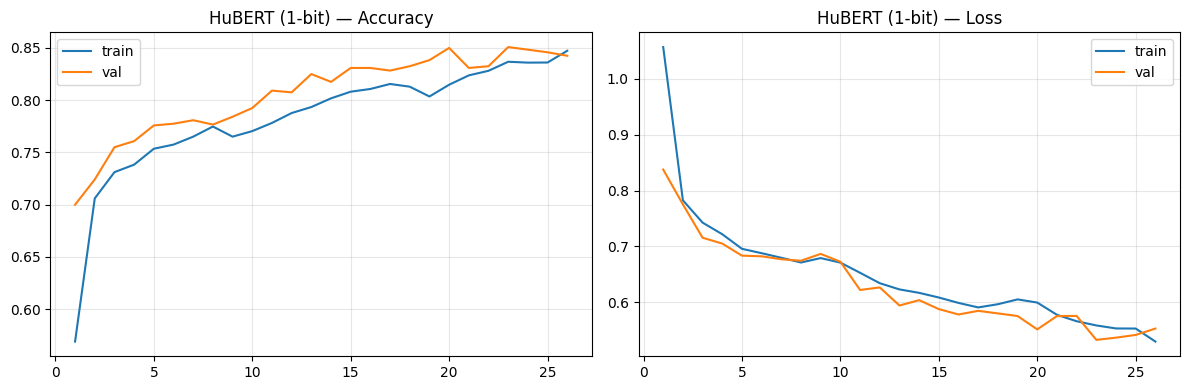

In [32]:
# ============================================================
# [1-bit] 7. Training curves
# ============================================================
hist_df_1 = plot_history(history_1, "HuBERT (1-bit)")


HuBERT (1-bit) — Test Set Performance
Accuracy   : 0.8692
Precision  : 0.8714
Recall     : 0.8692
F1 (macro) : 0.8687
ROC-AUC    : 0.9736
EER        : 0.0747

              precision    recall  f1-score   support

     Command     0.8951    0.9100    0.9025       300
Conversation     0.8610    0.7433    0.7979       300
     Numeric     0.9770    0.9933    0.9851       300
        Read     0.7523    0.8300    0.7892       300

    accuracy                         0.8692      1200
   macro avg     0.8714    0.8692    0.8687      1200
weighted avg     0.8714    0.8692    0.8687      1200



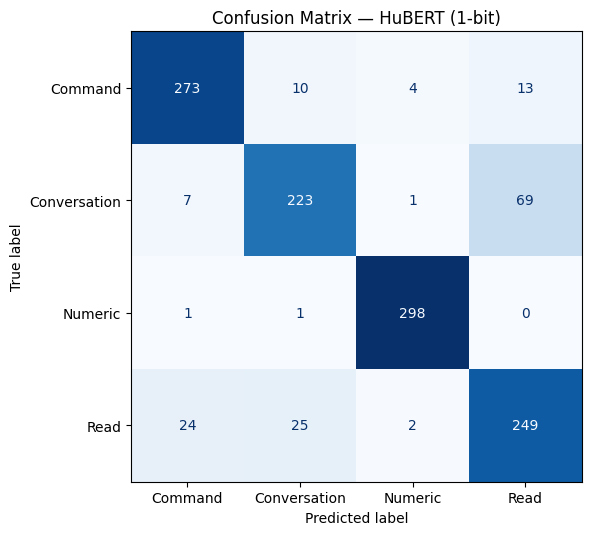

In [33]:
# ============================================================
# [1-bit] 8. Test evaluation (full report)
# ============================================================
model_1bit.load_state_dict(best_state_1)  # ensure best checkpoint (not last epoch) is evaluated
report_1bit = full_test_report(model_1bit, test_loader_1, tag="HuBERT (1-bit)")


In [34]:
# ============================================================
# [1-bit] 9. MFCC baseline
# ============================================================
baseline_1bit = run_mfcc_baseline(X_train_1, y_train_1, X_val_1, y_val_1, X_test_1, y_test_1, tag="1-bit")


[1-bit] MFCC + LogisticRegression baseline — Test Acc: 0.8258 | Macro-F1: 0.8252


---
# Final comparison — 16-bit vs 1-bit
---

In [35]:
# ============================================================
# Comparison — bootstrap CI + McNemar test + results table
# ============================================================
def bootstrap_ci_paired(labels, preds, metric_fn, n_boot=2000, seed=0):
    rng = np.random.RandomState(seed)
    n = len(labels)
    stats = []
    for _ in range(n_boot):
        idx = rng.randint(0, n, n)
        stats.append(metric_fn(labels[idx], preds[idx]))
    lo, hi = np.percentile(stats, [2.5, 97.5])
    return float(np.mean(stats)), float(lo), float(hi)


def mcnemar_test(labels, preds_a, preds_b):
    correct_a = (preds_a == labels)
    correct_b = (preds_b == labels)
    n01 = int(np.sum(correct_a & ~correct_b))
    n10 = int(np.sum(~correct_a & correct_b))
    if n01 + n10 == 0:
        return 1.0
    stat = (abs(n01 - n10) - 1) ** 2 / (n01 + n10)
    return 1 - chi2.cdf(stat, df=1)


acc_ci_16 = bootstrap_ci_paired(report_16bit["labels"], report_16bit["preds"], accuracy_score)
acc_ci_1 = bootstrap_ci_paired(report_1bit["labels"], report_1bit["preds"], accuracy_score)

print(f"HuBERT 16-bit test accuracy 95% bootstrap CI: mean={acc_ci_16[0]:.4f} [{acc_ci_16[1]:.4f}, {acc_ci_16[2]:.4f}]")
print(f"HuBERT 1-bit  test accuracy 95% bootstrap CI: mean={acc_ci_1[0]:.4f} [{acc_ci_1[1]:.4f}, {acc_ci_1[2]:.4f}]")

if len(report_16bit["labels"]) == len(report_1bit["labels"]):
    p_val = mcnemar_test(report_16bit["labels"], report_16bit["preds"], report_1bit["preds"])
    print(f"McNemar test (HuBERT 16-bit vs 1-bit), paired on the same test items: p = {p_val:.4f}")
else:
    print("Test sets have different sizes/orderings — McNemar's test needs paired predictions "
          "on the SAME items, so it is skipped here. Re-derive matched test sets if you need this.")

results_table = pd.DataFrame([
    {"condition": "16-bit", "model": "HuBERT (fine-tuned)", "accuracy": report_16bit["accuracy"],
     "f1_macro": report_16bit["f1_macro"], "roc_auc": report_16bit["roc_auc"], "eer": report_16bit["eer"]},
    {"condition": "16-bit", "model": "MFCC + LogReg", "accuracy": baseline_16bit["accuracy"],
     "f1_macro": baseline_16bit["macro_f1"], "roc_auc": float("nan"), "eer": float("nan")},
    {"condition": "1-bit", "model": "HuBERT (fine-tuned)", "accuracy": report_1bit["accuracy"],
     "f1_macro": report_1bit["f1_macro"], "roc_auc": report_1bit["roc_auc"], "eer": report_1bit["eer"]},
    {"condition": "1-bit", "model": "MFCC + LogReg", "accuracy": baseline_1bit["accuracy"],
     "f1_macro": baseline_1bit["macro_f1"], "roc_auc": float("nan"), "eer": float("nan")},
])
print(results_table.to_string(index=False))
results_table.to_csv(os.path.join(OUT_DIR, "hubert_results_table.csv"), index=False)


HuBERT 16-bit test accuracy 95% bootstrap CI: mean=0.9918 [0.9867, 0.9967]
HuBERT 1-bit  test accuracy 95% bootstrap CI: mean=0.8693 [0.8500, 0.8875]
McNemar test (HuBERT 16-bit vs 1-bit), paired on the same test items: p = 0.0000
condition               model  accuracy  f1_macro  roc_auc      eer
   16-bit HuBERT (fine-tuned)  0.991667  0.991673 0.999790 0.005000
   16-bit       MFCC + LogReg  0.904167  0.903917      NaN      NaN
    1-bit HuBERT (fine-tuned)  0.869167  0.868670 0.973626 0.074722
    1-bit       MFCC + LogReg  0.825833  0.825150      NaN      NaN


In [36]:
# ============================================================
# Optional — bring in the Wav2Vec2 numbers for a 3-way comparison
# ============================================================
# If you ran the companion Wav2Vec2 notebook in the same session (or reload its
# saved `results_table`/`report_*` objects), you can compare backbones directly:
#
# w2v2_16 = ...  # report_16bit['accuracy'] from the Wav2Vec2 notebook
# w2v2_1  = ...  # report_1bit['accuracy'] from the Wav2Vec2 notebook
# print(f"Wav2Vec2 16-bit acc: {w2v2_16:.4f}  vs  HuBERT 16-bit acc: {report_16bit['accuracy']:.4f}")
# print(f"Wav2Vec2 1-bit  acc: {w2v2_1:.4f}  vs  HuBERT 1-bit  acc: {report_1bit['accuracy']:.4f}")
#
# For a rigorous claim, run McNemar's test on the two backbones' predictions on
# the same held-out test items, and report bootstrap CIs for both rather than a
# single point-estimate delta.


## Reporting checklist

- [ ] This notebook runs a **single seed** per condition by default (`SEED = 42`) for
      clarity. For a publishable claim, rerun both PART A and PART B with 2–4 more
      seed values and report **mean ± std**, not one run.
- [ ] Confirm the leakage check found 0 duplicates in both conditions before trusting
      any test number.
- [ ] Report the MFCC baseline alongside HuBERT so the pretrained representation's
      contribution is quantified.
- [ ] If McNemar's `p > 0.05`, say the 16-bit vs 1-bit difference is not statistically
      distinguishable at this sample size rather than claiming a difference.
- [ ] If 1-bit underperforms substantially, treat that as a genuine robustness finding
      (domain mismatch between the pretrained CNN encoder and 1-bit/PDM-style audio),
      not something to tune away.
- [ ] For a genuine HuBERT-vs-Wav2Vec2 paper claim, evaluate **both backbones on the
      exact same test split and seeds**, then report paired statistics (McNemar / a
      paired bootstrap on the accuracy difference), not two separately-run numbers
      compared informally.
- [ ] Consider also reporting a **frozen-backbone (linear-probe) baseline** for both
      HuBERT and Wav2Vec2 — i.e. Stage 1 only, never running Stages 2–3 — since the
      original HuBERT paper's ablations show a meaningful part of its story is in how
      much a frozen representation already carries, before any fine-tuning.
